# Brain Tumor MRI Classification using CNN

## Objective

The objective of this project is to build a deep learning model capable of classifying brain MRI scans into four categories:

- Glioma
- Meningioma
- Pituitary Tumor
- No Tumor

Instead of training a CNN from scratch, a pretrained **Xception** model trained on ImageNet is used as the feature extractor (Transfer Learning). The final classification layers are customized for this specific medical imaging task.

## Importing Libraries

In [21]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import warnings
warnings.filterwarnings("ignore")

## Dataset

Dataset Source: **Brain Tumor MRI Dataset**

Downloaded directly using KaggleHub.

In [22]:
import kagglehub
path = Path(kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset"))
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset


## Creating DataFrames

In [23]:
def train_df(tr_path):
    classes, class_paths = zip(*[
        (label, os.path.join(tr_path, label, image))
        for label in os.listdir(tr_path)
        if os.path.isdir(os.path.join(tr_path, label))
        for image in os.listdir(os.path.join(tr_path, label))
    ])

    tr_df = pd.DataFrame({
        'Class Path': class_paths,
        'Class': classes
    })
    return tr_df


def test_df(ts_path):
    classes, class_paths = zip(*[
        (label, os.path.join(ts_path, label, image))
        for label in os.listdir(ts_path)
        if os.path.isdir(os.path.join(ts_path, label))
        for image in os.listdir(os.path.join(ts_path, label))
    ])

    ts_df = pd.DataFrame({
        'Class Path': class_paths,
        'Class': classes
    })
    return ts_df


tr_df = train_df(str(path) + '/Training')
ts_df = test_df(str(path) + '/Testing')

## Dataset Visualization

### Purpose

- Check class imbalance
- Understand dataset distribution
- Verify successful loading of all images

The dataset is relatively balanced across all four classes.
---

# Validation Split

The testing dataset was divided equally into:

- Validation Set
- Test Set

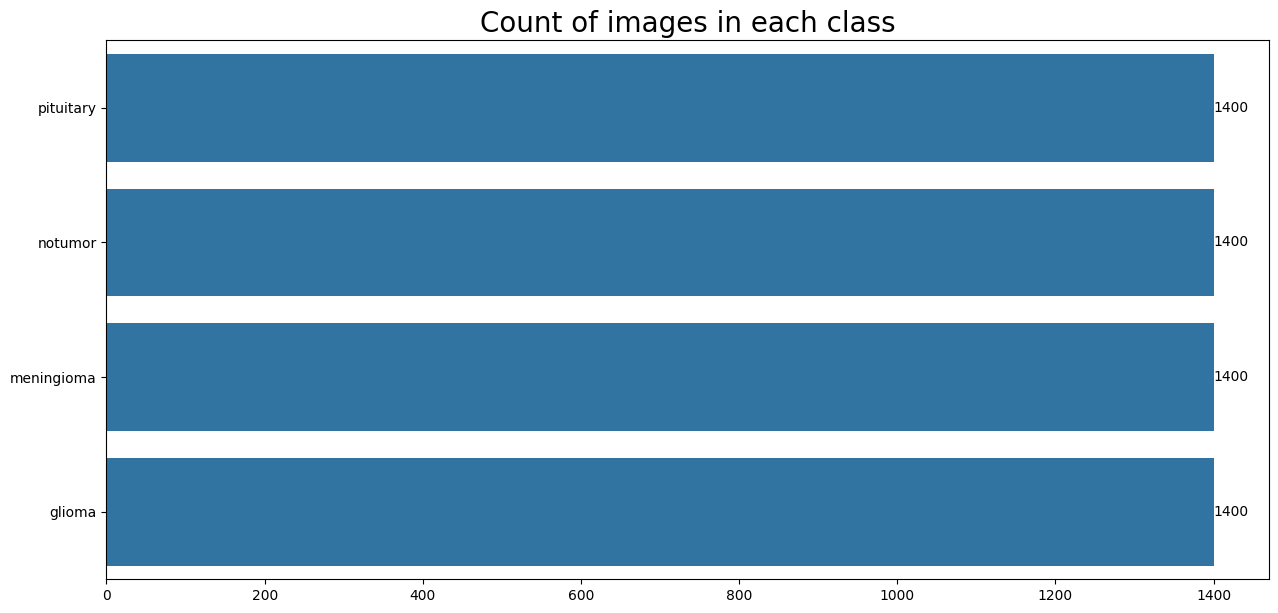

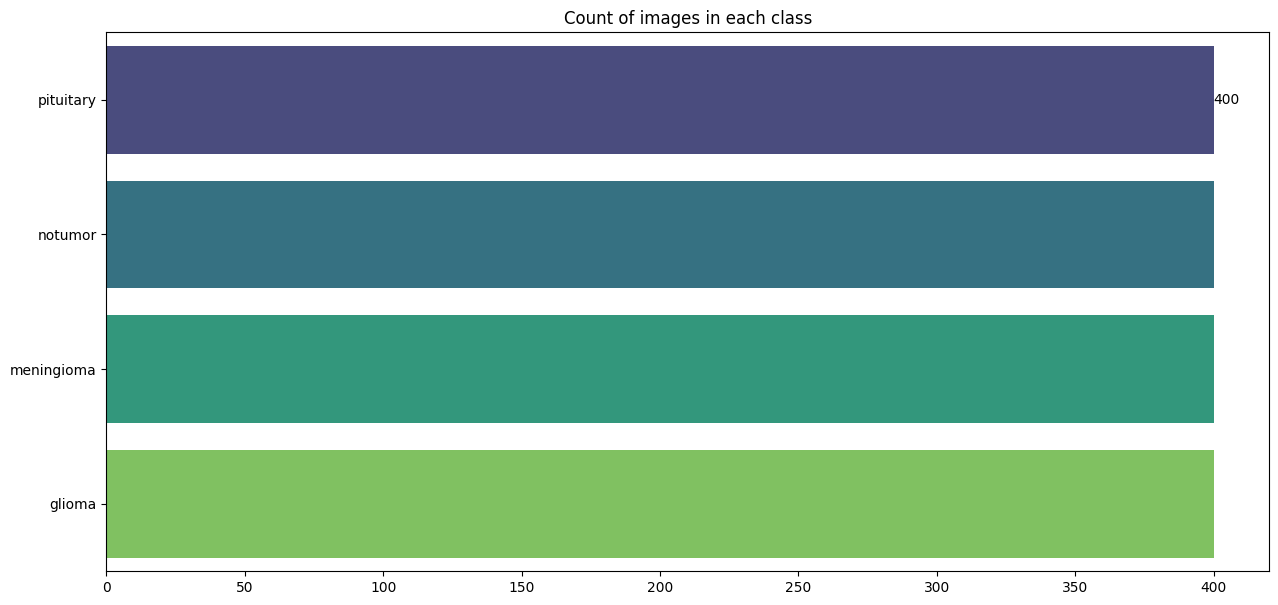

In [24]:
plt.figure(figsize=(15, 7))
ax = sns.countplot(data=tr_df, y="Class")

plt.title("Count of images in each class", fontsize=20)
plt.xlabel("")
plt.ylabel("")
ax.bar_label(ax.containers[0])

plt.show()

plt.figure(figsize=(15, 7))
ax = sns.countplot(data=ts_df, y="Class", palette="viridis")

ax.set(
    xlabel="",
    ylabel="",
    title="Count of images in each class"
)

ax.bar_label(ax.containers[0])

plt.show()

In [25]:
valid_df, ts_df = train_test_split(
    ts_df,
    train_size=0.5,
    random_state=20,
    stratify=ts_df["Class"]
)

## Image Preprocessing & Training Data generation

In [26]:
batch_size = 32
img_size = (299, 299)

train_datagen = ImageDataGenerator(
    rescale=1 / 255,
    brightness_range=(0.8, 1.2)
)

test_datagen = ImageDataGenerator(rescale=1 / 255)

tr_gen = train_datagen.flow_from_dataframe(
    tr_df,
    x_col="Class Path",
    y_col="Class",
    batch_size=batch_size,
    target_size=img_size
)

valid_gen = train_datagen.flow_from_dataframe(
    valid_df,
    x_col="Class Path",
    y_col="Class",
    batch_size=batch_size,
    target_size=img_size
)

ts_gen = test_datagen.flow_from_dataframe(
    ts_df,
    x_col="Class Path",
    y_col="Class",
    batch_size=16,
    target_size=img_size,
    shuffle=False
)

Found 5600 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.
Found 800 validated image filenames belonging to 4 classes.


## Visualizing Sample Images

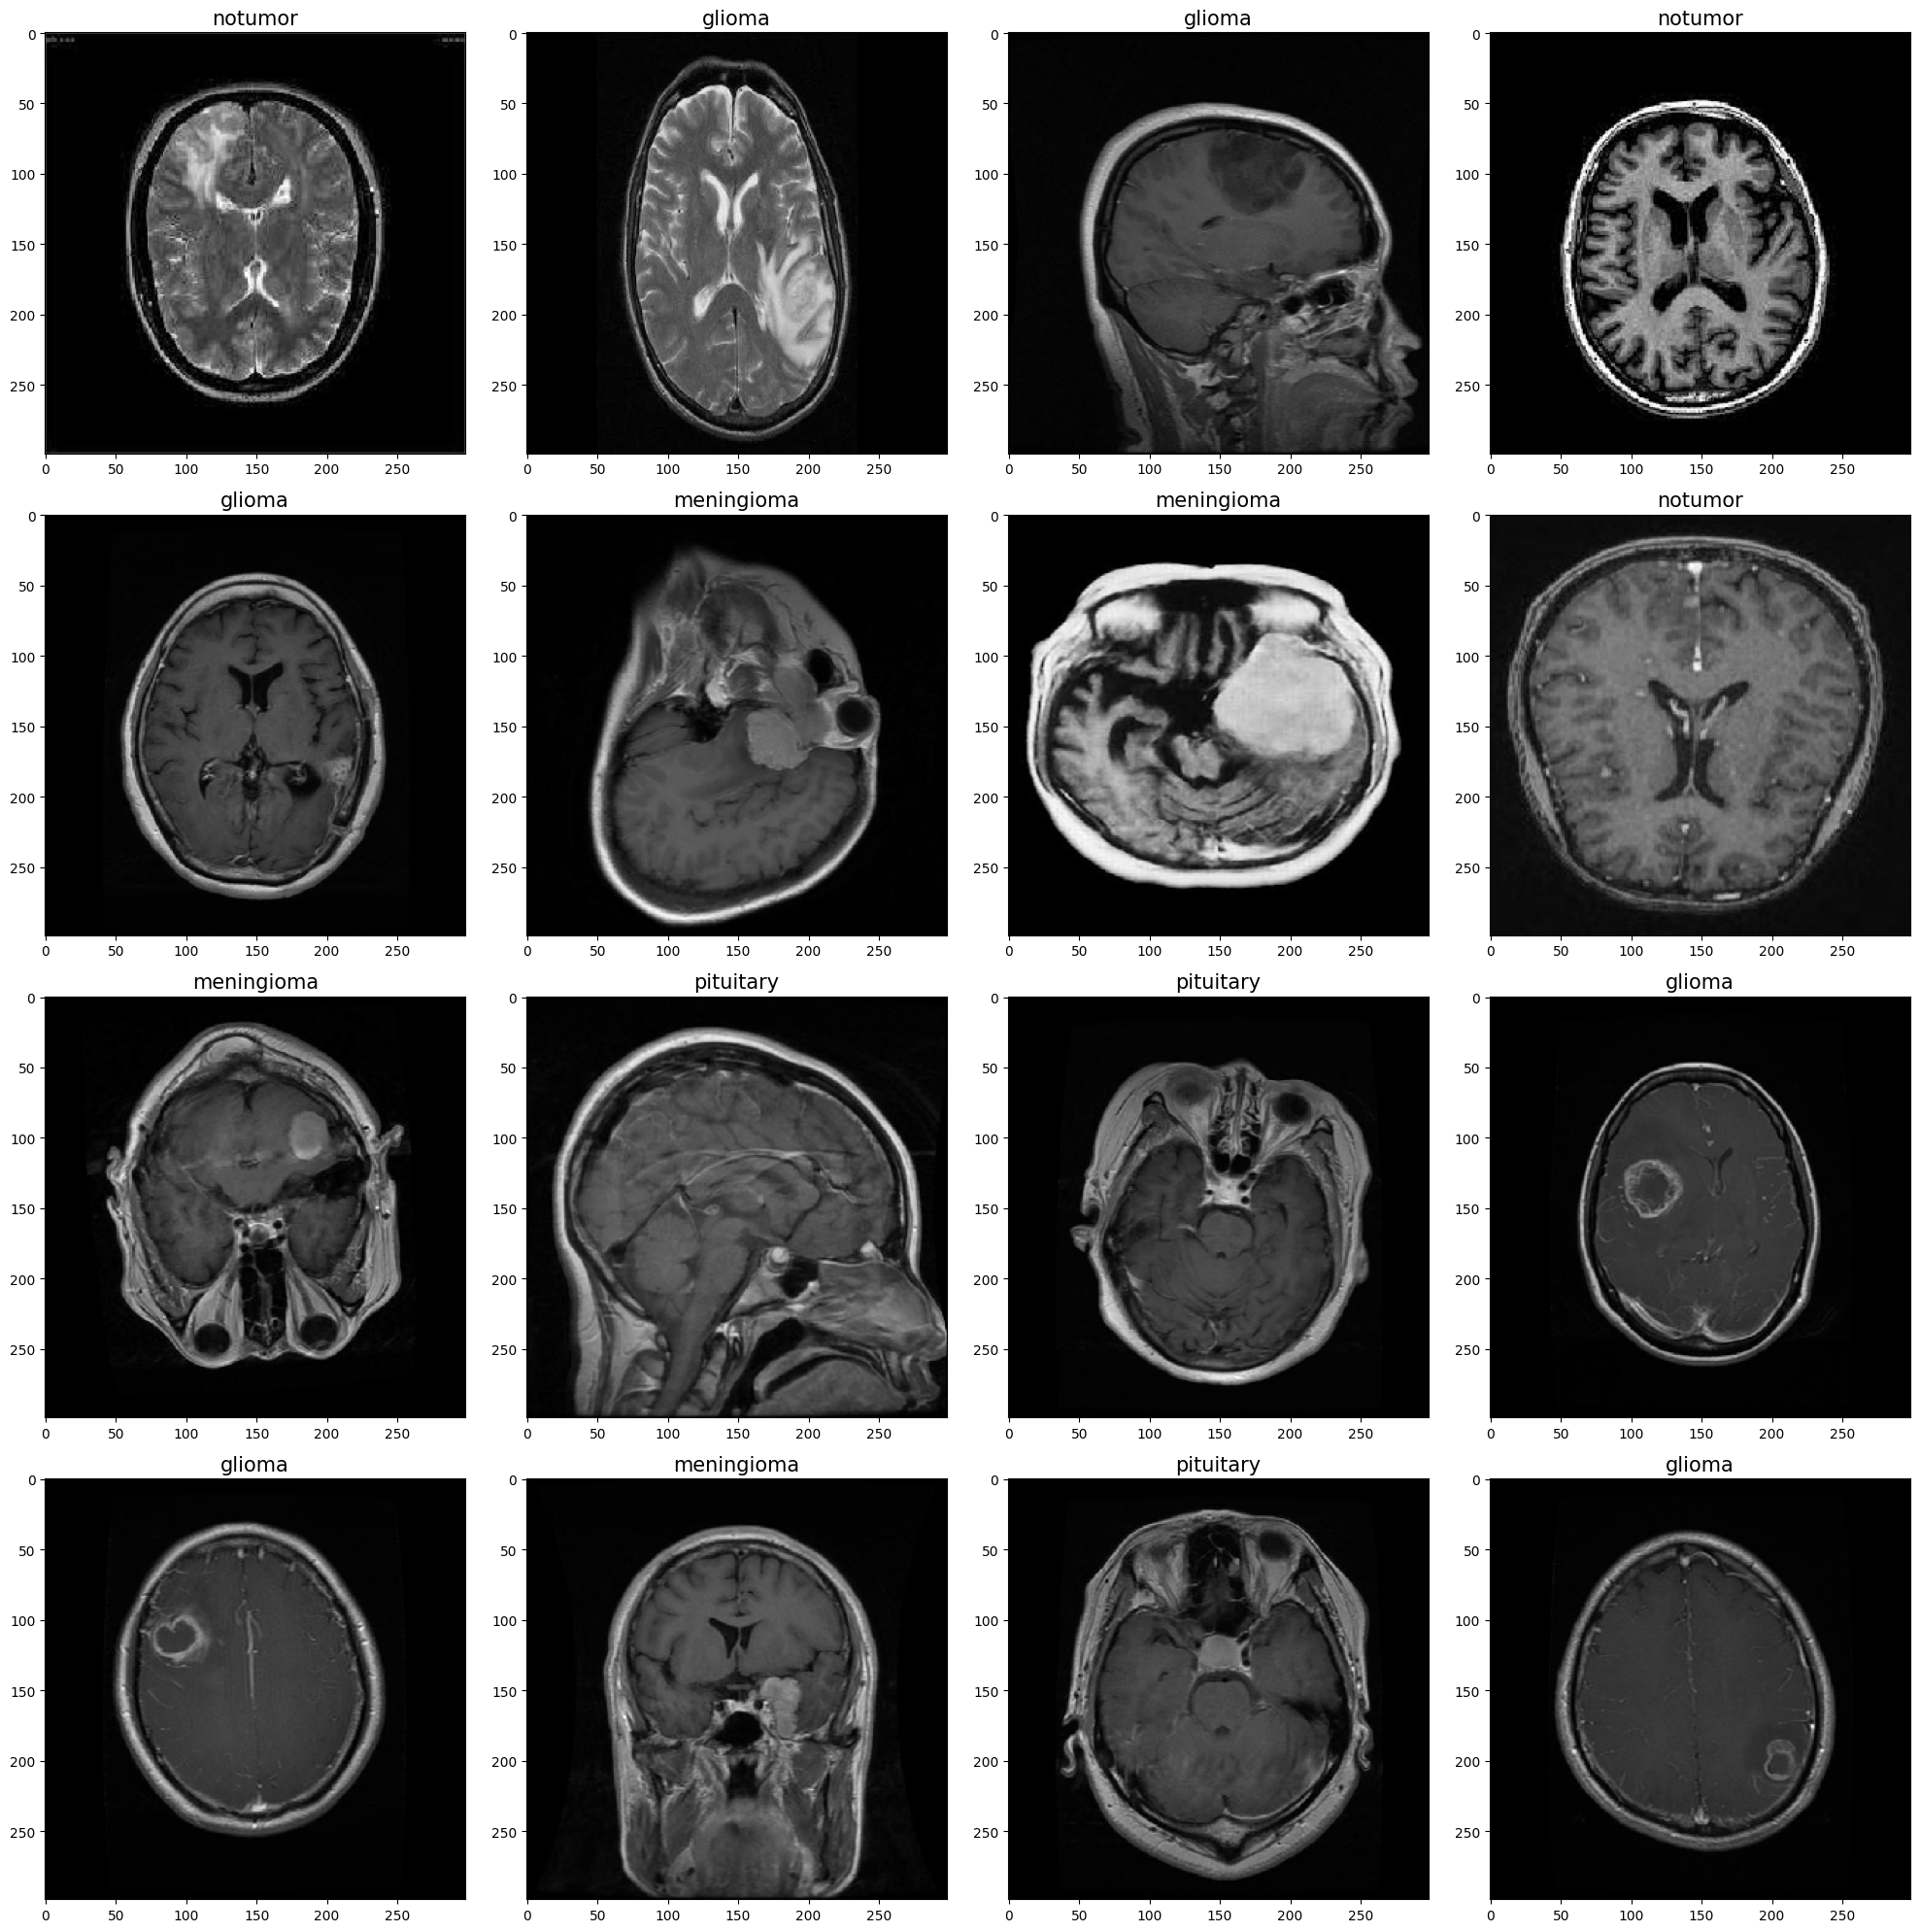

In [27]:
class_dict = tr_gen.class_indices
classes = list(class_dict.keys())

images, labels = next(ts_gen)

plt.figure(figsize=(20, 20))

for i, (image, label) in enumerate(zip(images, labels)):
    plt.subplot(4, 4, i + 1)
    plt.imshow(image)
    plt.title(classes[np.argmax(label)], fontsize=15)

plt.tight_layout()
plt.show()

## Building the Transfer Learning Model

In [28]:
img_shape = (299, 299, 3)

base_model = tf.keras.applications.Xception(
    include_top=False,
    weights="imagenet",
    input_shape=img_shape,
    pooling="max"
)

# Uncomment to freeze the pretrained layers
# for layer in base_model.layers:
#     layer.trainable = False

model = Sequential([
    base_model,
    Flatten(),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.25),
    Dense(4, activation="softmax")
])

model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=[
        "accuracy",
        Precision(),
        Recall()
    ]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 2048)           │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

## Model Architecture

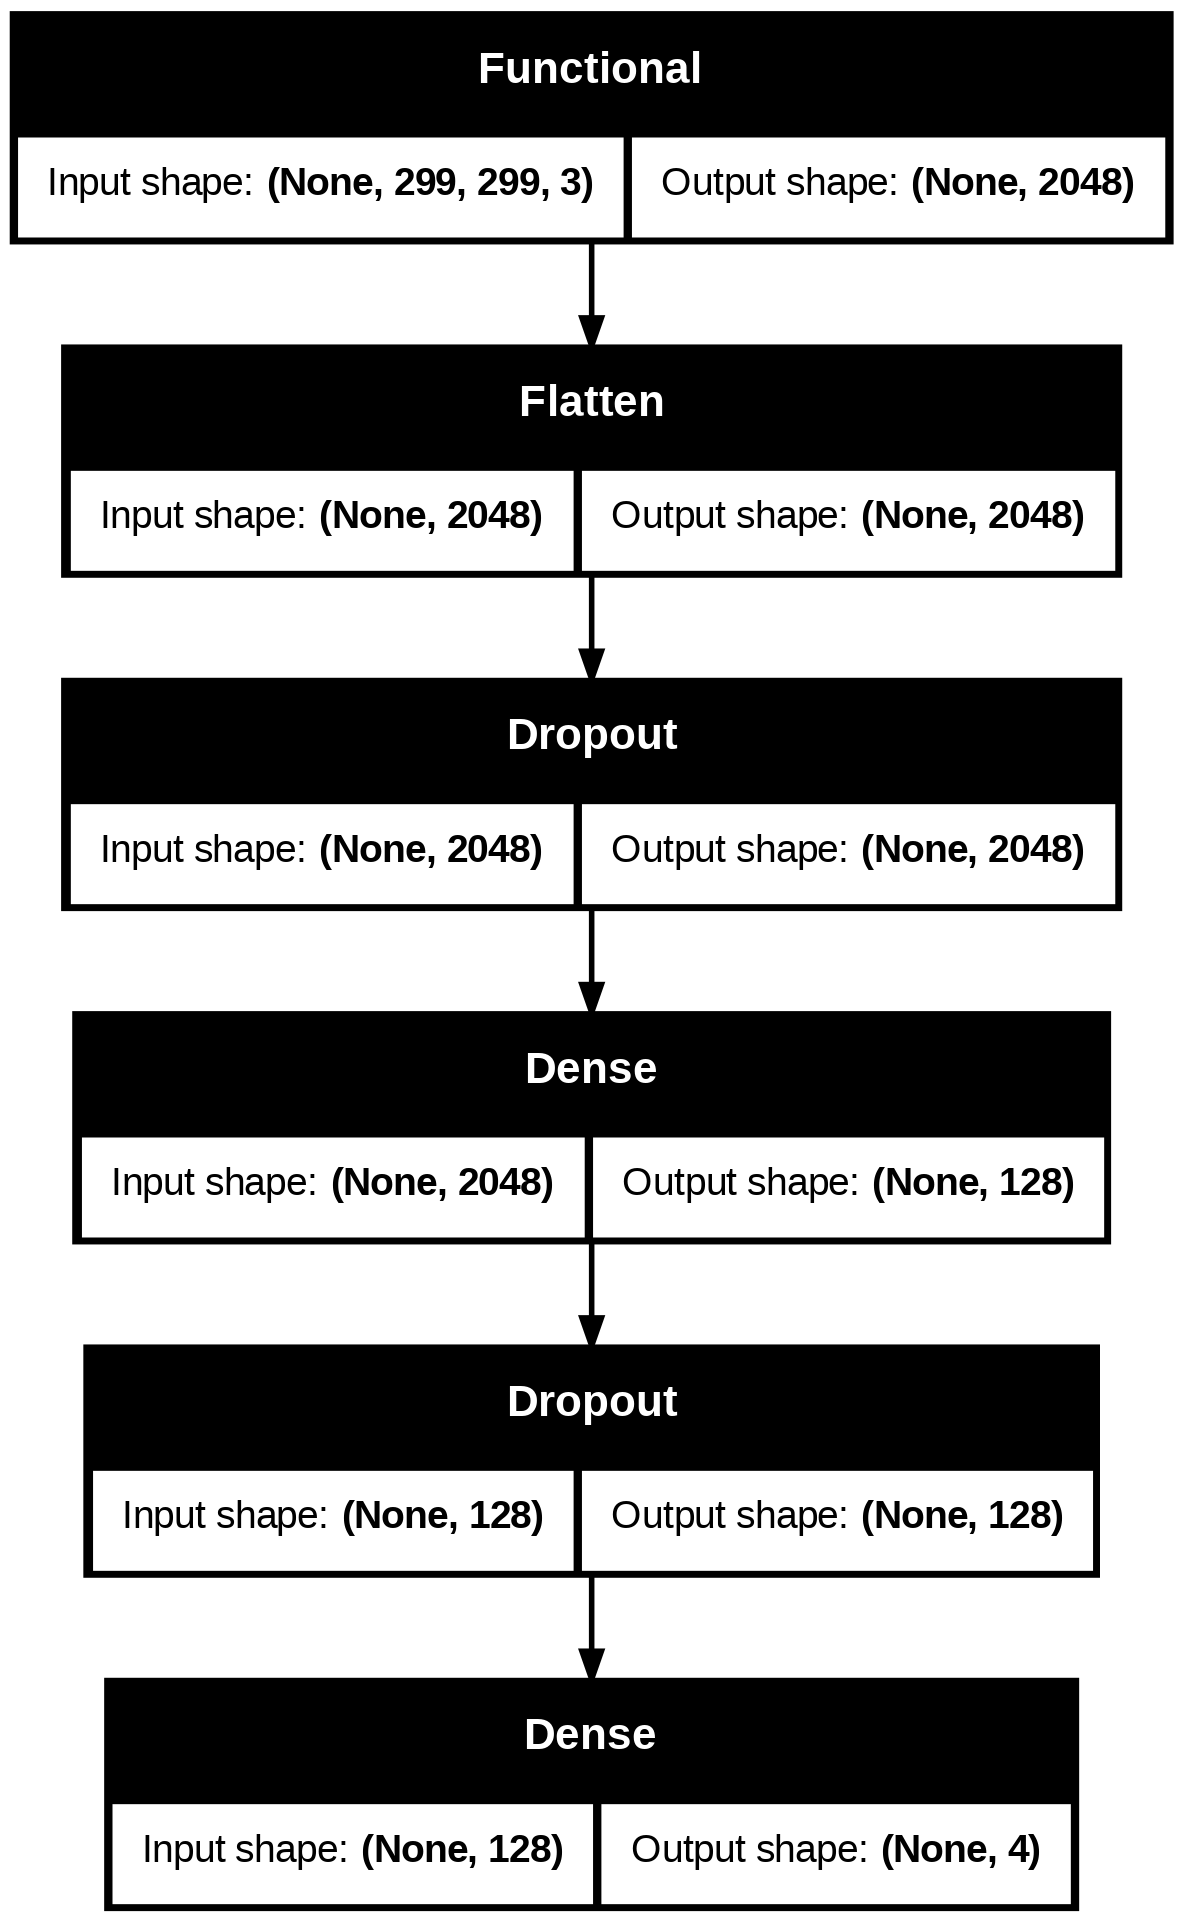

In [29]:
tf.keras.utils.plot_model(model, show_shapes=True)

# Model Training

In [30]:
hist = model.fit(
    tr_gen,
    epochs=5,
    validation_data=valid_gen,
    shuffle=False
)

Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 231s 988ms/step - accuracy: 0.8729 - loss: 0.3642 - precision_2: 0.9109 - recall_2: 0.8305 - val_accuracy: 0.9075 - val_loss: 0.3254 - val_precision_2: 0.9119 - val_recall_2: 0.9062
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 162s 927ms/step - accuracy: 0.9748 - loss: 0.0798 - precision_2: 0.9763 - recall_2: 0.9720 - val_accuracy: 0.9100 - val_loss: 0.3778 - val_precision_2: 0.9140 - val_recall_2: 0.9038
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 162s 926ms/step - accuracy: 0.9934 - loss: 0.0250 - precision_2: 0.9936 - recall_2: 0.9930 - val_accuracy: 0.9300 - val_loss: 0.3720 - val_precision_2: 0.9312 - val_recall_2: 0.9300
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 162s 926ms/step - accuracy: 0.9946 - loss: 0.0172 - precision_2: 0.9946 - recall_2: 0.9943 - val_accuracy: 0.9362 - val_loss: 0.3322 - val_precision_2: 0.9409 - val_recall_2: 0.9350
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 162s 925ms/step - accuracy: 0.9946 - loss: 0.0160 - precision_2: 0.9950 - rec

Observation:

- Very fast convergence
- Stable learning
- Minimal overfitting
- Excellent validation performance

In [31]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'precision_2', 'recall_2', 'val_accuracy', 'val_loss', 'val_precision_2', 'val_recall_2'])

# Model Evaluation

In [32]:
train_score = model.evaluate(tr_gen, verbose=1)
valid_score = model.evaluate(valid_gen, verbose=1)
test_score = model.evaluate(ts_gen, verbose=1)

print(f"Train Loss: {train_score[0]:.4f}")
print(f"Train Accuracy: {train_score[1] * 100:.2f}%")
print("-" * 20)

print(f"Validation Loss: {valid_score[0]:.4f}")
print(f"Validation Accuracy: {valid_score[1] * 100:.2f}%")
print("-" * 20)

print(f"Test Loss: {test_score[0]:.4f}")
print(f"Test Accuracy: {test_score[1] * 100:.2f}%")

175/175 ━━━━━━━━━━━━━━━━━━━━ 45s 258ms/step - accuracy: 0.9964 - loss: 0.0126 - precision_2: 0.9964 - recall_2: 0.9964
25/25 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.9413 - loss: 0.3916 - precision_2: 0.9413 - recall_2: 0.9413
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step - accuracy: 0.9463 - loss: 0.4456 - precision_2: 0.9463 - recall_2: 0.9463
Train Loss: 0.0126
Train Accuracy: 99.64%
--------------------
Validation Loss: 0.3916
Validation Accuracy: 94.13%
--------------------
Test Loss: 0.4456
Test Accuracy: 94.63%


50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 113ms/step


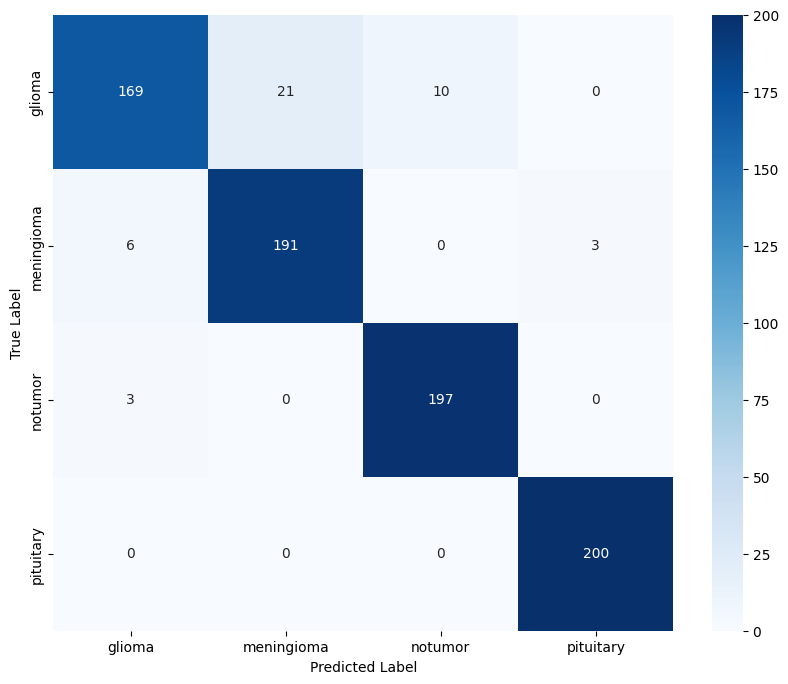

              precision    recall  f1-score   support

           0       0.95      0.84      0.89       200
           1       0.90      0.95      0.93       200
           2       0.95      0.98      0.97       200
           3       0.99      1.00      0.99       200

    accuracy                           0.95       800
   macro avg       0.95      0.95      0.95       800
weighted avg       0.95      0.95      0.95       800



In [33]:
preds = model.predict(ts_gen)
y_pred = np.argmax(preds, axis=1)

cm = confusion_matrix(ts_gen.classes, y_pred)

labels = list(class_dict.keys())

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print(classification_report(ts_gen.classes, y_pred))

# Prediction on Individual Images

In [34]:
def predict(img_path):
    labels = list(class_dict.keys())

    img = Image.open(img_path).resize((299, 299))

    img_array = np.asarray(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    probabilities = prediction[0]

    plt.figure(figsize=(12, 12))

    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probabilities)

    plt.xlabel("Probability")

    ax = plt.gca()
    ax.bar_label(bars, fmt="%.2f")

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


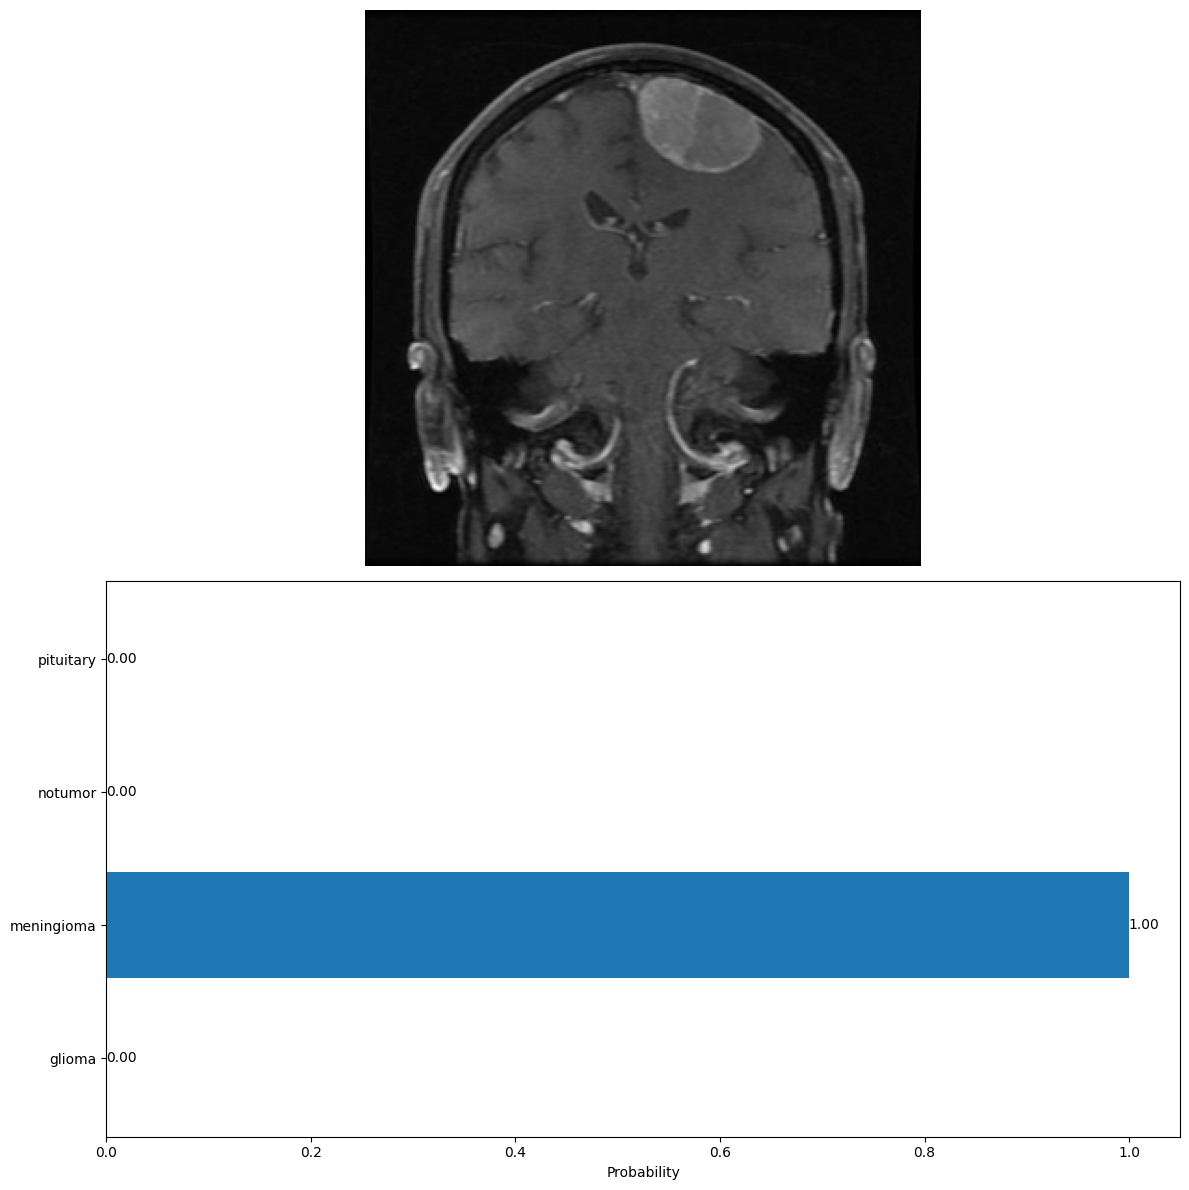

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


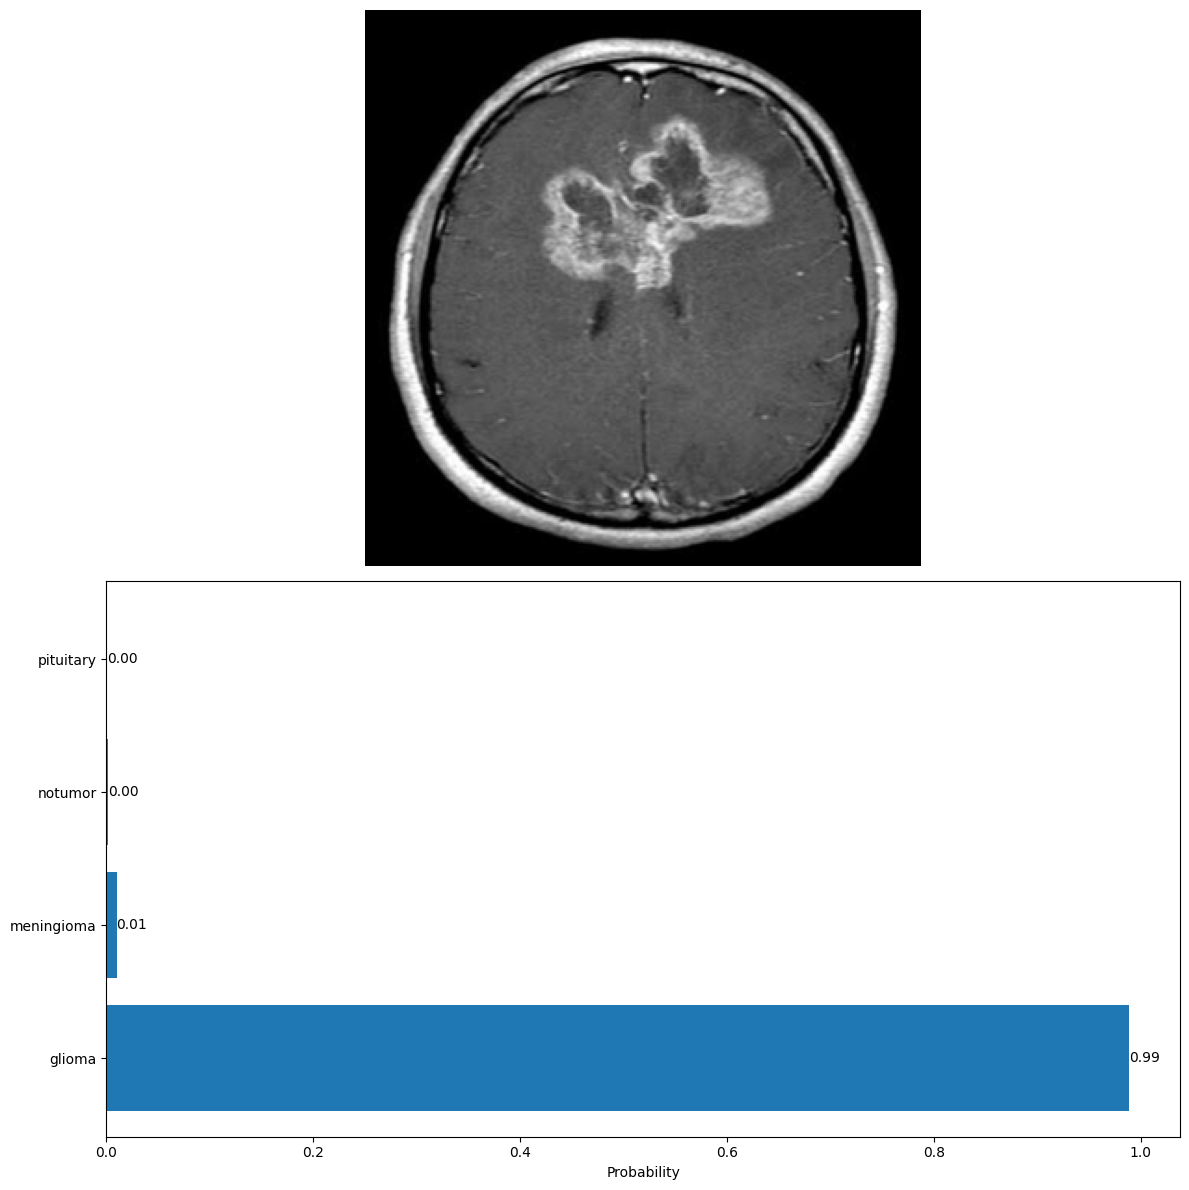

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


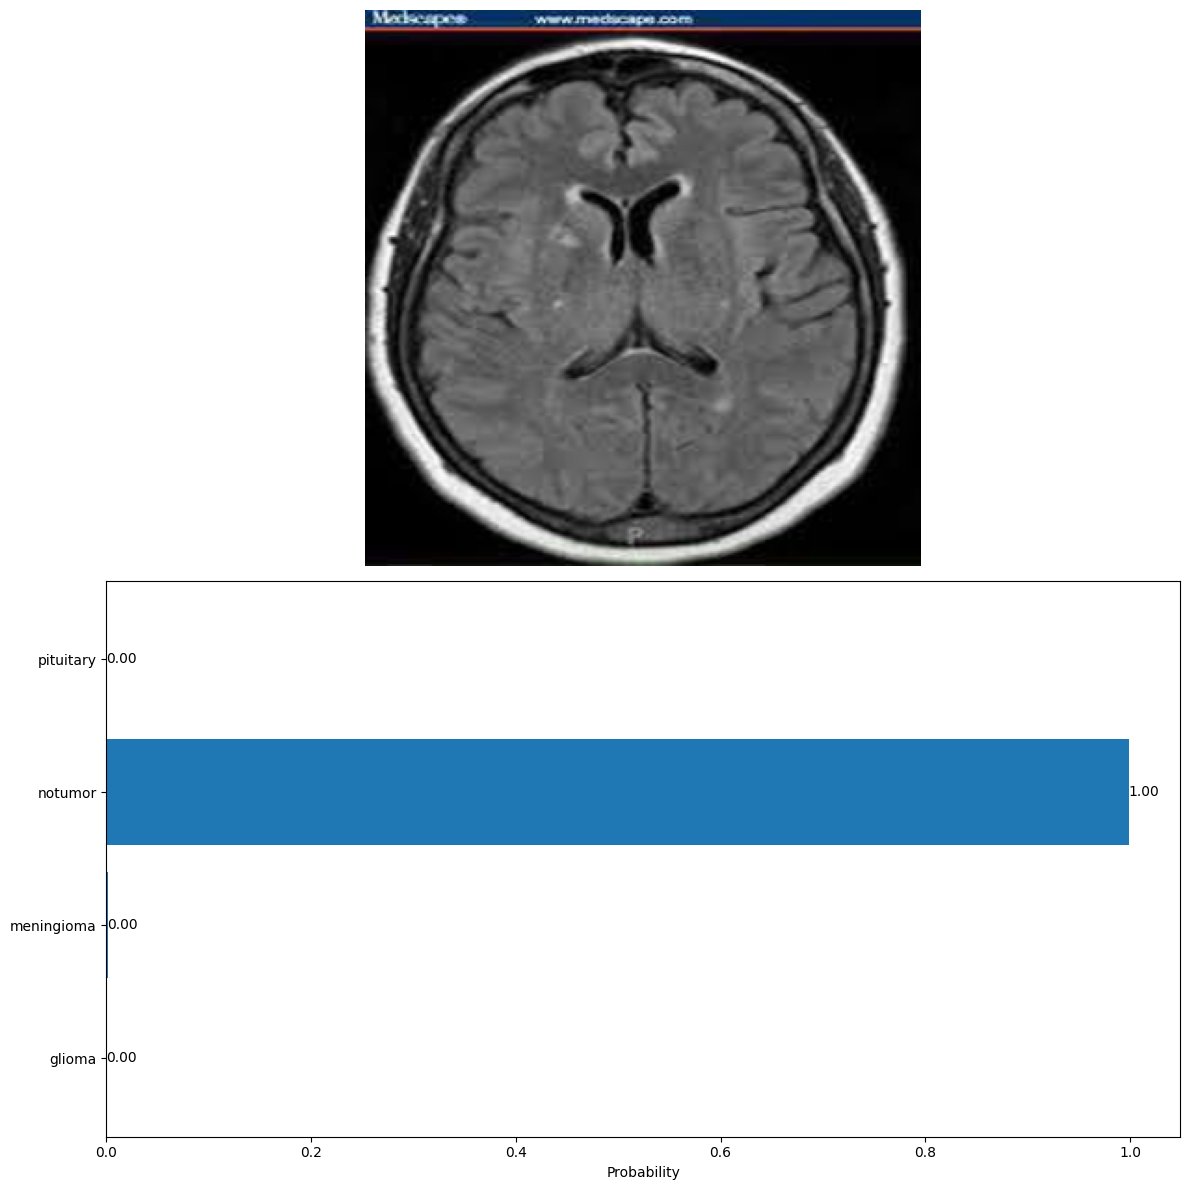

In [38]:
predict(str(path)+ "/Testing/meningioma/Te-me_1.jpg")
predict(str(path)+"/Testing/glioma/Te-gl_1.jpg")
predict(str(path)+"/Testing/notumor/Te-no_1.jpg")
